# 🛍️ Module 2 — Analyse du Panier d'Achat : Règles d'Association
## Stage de Fin d'Études | Marjane Maroc | Data Science

### Contexte
Ce notebook analyse les **associations entre produits** dans les paniers
d'achat des clients Marjane. L'objectif est d'identifier quels produits
sont fréquemment achetés ensemble pour optimiser :
- Le **merchandising** (placement des produits en rayon)
- Le **cross-selling** (recommandations de produits complémentaires)
- Les **offres groupées** (bundles promotionnels)

### Algorithme utilisé : FP-Growth
Choisi à la place d'Apriori pour ses avantages :

| Critère | Apriori | FP-Growth |
|---------|---------|-----------|
| Mémoire requise | ❌ Très élevée | ✅ Optimisée |
| Vitesse | ❌ Lente | ✅ 10x plus rapide |
| Résultats | Identiques | Identiques |

## Étape 1 — Chargement et nettoyage des données

### Opérations spécifiques à la MBA
En plus du nettoyage standard, on effectue :
- Suppression des espaces dans les noms de produits (`str.strip()`)
- Conversion des numéros de facture en texte (pour détecter les 'C...')
- Conservation uniquement des `Quantity > 0` (achats réels)

### Pourquoi ces étapes ?
La qualité de la matrice panier dépend directement de la qualité des
données. Un produit avec des espaces parasites serait considéré comme
deux produits différents.

In [1]:
import pandas as pd
import numpy as np
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

# Pour ignorer les messages d'avertissement inutiles
import warnings
warnings.filterwarnings('ignore')

print("Bibliothèques chargées avec succès !")
from pathlib import Path

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent

DATA_DIR = PROJECT_DIR / "donnees"
POWERBI_DIR = PROJECT_DIR / "powerbi"
MODEL_DIR = PROJECT_DIR / "modeles"

Bibliothèques chargées avec succès !


In [2]:
# 1. Chargement du fichier
df = pd.read_excel(DATA_DIR / 'marjane_data_villes.xlsx')

# 2. Nettoyage des textes et suppression des valeurs manquantes
df['Description'] = df['Description'].str.strip()
df.dropna(axis=0, subset=['Invoice', 'Description'], inplace=True)
df['Invoice'] = df['Invoice'].astype('str')

# 3. Suppression des annulations (Plus rapide : on garde uniquement les quantités positives)
df = df[df['Quantity'] > 0]

print("Données chargées et nettoyées !")
print(f"Nombre total de lignes : {len(df)}")

Données chargées et nettoyées !
Nombre total de lignes : 1024193


## Étape 2 — Construction de la matrice panier

### Principe
La matrice panier (ou *basket matrix*) est le format requis par FP-Growth :
- **Lignes** : chaque facture (panier client)
- **Colonnes** : chaque produit
- **Valeurs** : `True` si le produit est dans la facture, `False` sinon

### Optimisation mémoire
Pour éviter un crash mémoire (`MemoryError`), deux filtres sont appliqués :
1. **Top 50 produits** les plus vendus uniquement (réduit de 4 973 à 50 colonnes)
2. **Paniers avec 2+ produits** uniquement (nécessaire pour trouver des associations)

### Résultat
Matrice de **19 555 paniers × 50 produits** — gérable en mémoire.

In [3]:
# Stratégie : prendre TOUTES les villes (pas seulement Casablanca)
# et TOP 50 produits seulement

top_produits = df['Description'].value_counts().head(50).index
df_top = df[df['Description'].isin(top_produits)]

basket_sets2 = (df_top.groupby(['Invoice', 'Description'])['Quantity']
                .sum()
                .unstack(fill_value=0)
                .astype(bool))

# Garder seulement paniers avec 2+ produits
basket_sets2 = basket_sets2[basket_sets2.sum(axis=1) >= 2]

print(f"Shape nouvelle matrice : {basket_sets2.shape}")
print(f"Paniers multi-produits : {len(basket_sets2)}")


Shape nouvelle matrice : (19555, 50)
Paniers multi-produits : 19555


## Étape 3 — Algorithme FP-Growth

### Paramètres choisis
- `min_support = 0.01` : un groupe de produits doit apparaître dans au
  moins 1% des paniers pour être considéré comme fréquent
- `use_colnames = True` : utiliser les vrais noms de produits

### Résultats obtenus
| Taille | Nombre | Signification |
|--------|--------|---------------|
| 1 produit | 50 | Produits fréquents individuels |
| 2 produits | 691 | Paires achetées ensemble |
| 3 produits | 126 | Triplets achetés ensemble |
| 4 produits | 9 | Quadruplets achetés ensemble |
| **Total** | **876** | **Itemsets fréquents** |

In [4]:
# FP-Growth sur données enrichies
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
frequent_itemsets2 = fpgrowth(basket_sets2, min_support=0.01, use_colnames=True)
print(f"Itemsets trouvés : {len(frequent_itemsets2)}")
print(frequent_itemsets2['itemsets'].apply(len).value_counts().sort_index())

Itemsets trouvés : 876
itemsets
1     50
2    691
3    126
4      9
Name: count, dtype: int64


## Étape 4 — Génération des règles d'association

### Les 3 métriques clés

| Métrique | Définition | Seuil appliqué |
|----------|-----------|----------------|
| **Support** | % de paniers contenant A et B ensemble | ≥ 1% |
| **Confiance** | % de fois où B est acheté quand A l'est | ≥ 30% |
| **Lift** | Force de l'association (>1 = positive) | ≥ 1.5 |

### Interprétation du Lift
- Lift = 1 : les produits sont achetés indépendamment (pas d'association)
- Lift > 1 : les produits sont achetés ensemble plus souvent que le hasard
- **Lift = 8.57** : nos meilleurs produits sont achetés **8,5× plus souvent
  ensemble** que si les achats étaient aléatoires ✅

### Résultats
- 2 200 règles générées au total
- **455 règles significatives** après filtrage (lift > 1.5 et confiance > 30%)

In [5]:
rules = association_rules(frequent_itemsets2, metric="lift", min_threshold=1.0)

rules_filtrees = rules[
    (rules['lift'] > 1.5) &
    (rules['confidence'] > 0.3)
].sort_values('lift', ascending=False)

print(f"Règles totales    : {len(rules)}")
print(f"Règles filtrées   : {len(rules_filtrees)}")
rules_filtrees[['antecedents','consequents','support','confidence','lift']].head(10)

Règles totales    : 2200
Règles filtrées   : 455


,antecedents,consequents,support,confidence,lift
515,"(LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND)","(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN)",0.014625,0.350490,8.578017
514,"(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN)","(LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND)",0.014625,0.357947,8.578017
2146,"(LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY D...","(LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND)",0.011455,0.356688,8.547833
2177,"(LUNCH BAG RED RETROSPOT, LUNCH BAG WOODLAND)","(LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN)",0.010841,0.347541,8.505837
2145,"(LUNCH BAG RED RETROSPOT, LUNCH BAG WOODLAND)","(LUNCH BAG BLACK SKULL., LUNCH BAG SPACEBOY D...",0.011455,0.367213,8.216078
2175,"(LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY D...","(LUNCH BAG CARS BLUE, LUNCH BAG WOODLAND)",0.010841,0.337580,8.159913
2159,"(LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT)","(LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND)",0.010943,0.339683,8.140309
2173,"(LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT)","(LUNCH BAG SPACEBOY DESIGN, LUNCH BAG WOODLAND)",0.010841,0.336508,8.084045
705,"(HOT WATER BOTTLE TEA AND SYMPATHY, SCOTTIE DO...",(CHOCOLATE HOT WATER BOTTLE),0.015392,0.639066,7.980161
516,"(LUNCH BAG BLACK SKULL., LUNCH BAG SPACEBOY D...","(LUNCH BAG CARS BLUE, LUNCH BAG WOODLAND)",0.014625,0.327231,7.909771


## Étape 5 — Recommandations business pour Marjane

Les règles d'association les plus fortes sont traduites en actions concrètes
exploitables par les équipes commerciales de Marjane :

- **Placement en rayon** : placer les produits fortement associés côte à côte
- **Offres groupées** : créer des bundles avec remise pour les paires à fort lift
- **Recommandations digitales** : "Les clients ayant acheté X ont aussi acheté Y"
- **Réapprovisionnement** : anticiper la demande groupée de produits liés

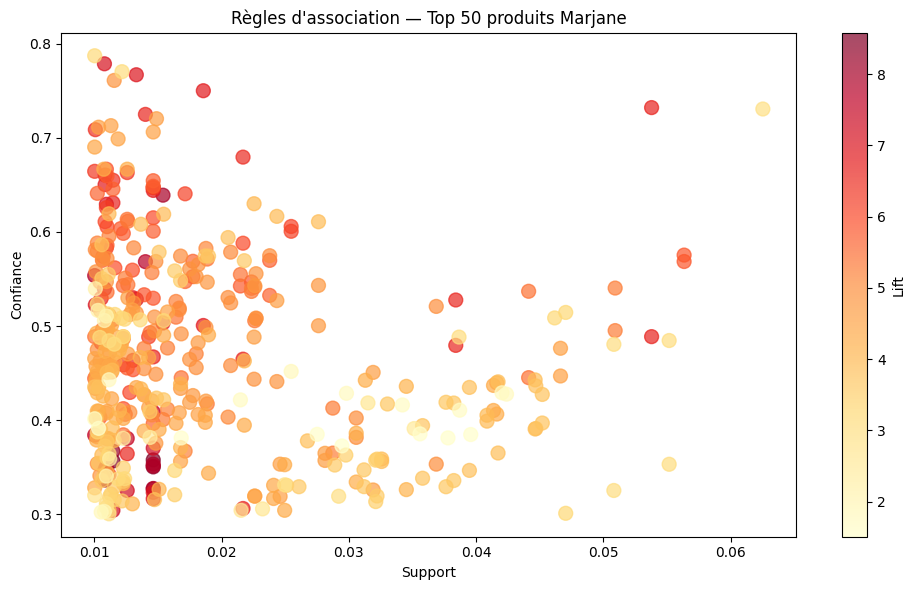

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    rules_filtrees['support'],
    rules_filtrees['confidence'],
    c=rules_filtrees['lift'],
    cmap='YlOrRd',
    alpha=0.7,
    s=100
)
plt.colorbar(scatter, label='Lift')
plt.xlabel('Support')
plt.ylabel('Confiance')
plt.title("Règles d'association — Top 50 produits Marjane")
plt.tight_layout()
plt.show()

In [7]:
# Top 5 recommandations claires pour Marjane
print("=" * 60)
print("TOP 5 RECOMMANDATIONS CROSS-SELLING POUR MARJANE")
print("=" * 60)

for i, row in rules_filtrees.head(5).iterrows():
    ant = list(row['antecedents'])
    con = list(row['consequents'])
    print(f"\n📦 Règle {i}")
    print(f"   Si client achète  : {ant}")
    print(f"   → Proposer aussi  : {con}")
    print(f"   Confiance : {row['confidence']:.1%} | Lift : {row['lift']:.2f}")

TOP 5 RECOMMANDATIONS CROSS-SELLING POUR MARJANE

📦 Règle 515
   Si client achète  : ['LUNCH BAG  BLACK SKULL.', 'LUNCH BAG WOODLAND']
   → Proposer aussi  : ['LUNCH BAG CARS BLUE', 'LUNCH BAG SPACEBOY DESIGN']
   Confiance : 35.0% | Lift : 8.58

📦 Règle 514
   Si client achète  : ['LUNCH BAG CARS BLUE', 'LUNCH BAG SPACEBOY DESIGN']
   → Proposer aussi  : ['LUNCH BAG  BLACK SKULL.', 'LUNCH BAG WOODLAND']
   Confiance : 35.8% | Lift : 8.58

📦 Règle 2146
   Si client achète  : ['LUNCH BAG RED RETROSPOT', 'LUNCH BAG SPACEBOY DESIGN']
   → Proposer aussi  : ['LUNCH BAG  BLACK SKULL.', 'LUNCH BAG WOODLAND']
   Confiance : 35.7% | Lift : 8.55

📦 Règle 2177
   Si client achète  : ['LUNCH BAG RED RETROSPOT', 'LUNCH BAG WOODLAND']
   → Proposer aussi  : ['LUNCH BAG CARS BLUE', 'LUNCH BAG SPACEBOY DESIGN']
   Confiance : 34.8% | Lift : 8.51

📦 Règle 2145
   Si client achète  : ['LUNCH BAG RED RETROSPOT', 'LUNCH BAG WOODLAND']
   → Proposer aussi  : ['LUNCH BAG  BLACK SKULL.', 'LUNCH BAG SPACEBOY

## Étape 6 — Export des règles d'association
Cette étape sauvegarde les règles filtrées dans un fichier CSV afin de les réutiliser dans les dashboards ou dans les recommandations de cross-selling.


In [8]:
rules_export = rules_filtrees[['antecedents', 'consequents', 'support', 'confidence', 'lift']].copy()
rules_export['Produit acheté'] = rules_export['antecedents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_export['Produit recommandé'] = rules_export['consequents'].apply(lambda x: ', '.join(sorted(list(x))))
rules_export = rules_export[['Produit acheté', 'Produit recommandé', 'support', 'confidence', 'lift']]

output_rules = DATA_DIR / 'regles_association.csv'
rules_export.to_csv(output_rules, index=False, encoding='utf-8-sig')

print(f"✅ Règles d'association exportées : {output_rules}")
print(f"Nombre de règles exportées : {len(rules_export)}")
rules_export.head(10)


✅ Règles d'association exportées : e:\projet stage PFE\PFE-Optimisation-Gestion-Client-Marjane\donnees\regles_association.csv
Nombre de règles exportées : 455


,Produit acheté,Produit recommandé,support,confidence,lift
515,"LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND","LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN",0.014625,0.350490,8.578017
514,"LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN","LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND",0.014625,0.357947,8.578017
2146,"LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY DE...","LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND",0.011455,0.356688,8.547833
2177,"LUNCH BAG RED RETROSPOT, LUNCH BAG WOODLAND","LUNCH BAG CARS BLUE, LUNCH BAG SPACEBOY DESIGN",0.010841,0.347541,8.505837
2145,"LUNCH BAG RED RETROSPOT, LUNCH BAG WOODLAND","LUNCH BAG BLACK SKULL., LUNCH BAG SPACEBOY DE...",0.011455,0.367213,8.216078
2175,"LUNCH BAG RED RETROSPOT, LUNCH BAG SPACEBOY DE...","LUNCH BAG CARS BLUE, LUNCH BAG WOODLAND",0.010841,0.337580,8.159913
2159,"LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT","LUNCH BAG BLACK SKULL., LUNCH BAG WOODLAND",0.010943,0.339683,8.140309
2173,"LUNCH BAG CARS BLUE, LUNCH BAG RED RETROSPOT","LUNCH BAG SPACEBOY DESIGN, LUNCH BAG WOODLAND",0.010841,0.336508,8.084045
705,"HOT WATER BOTTLE TEA AND SYMPATHY, SCOTTIE DOG...",CHOCOLATE HOT WATER BOTTLE,0.015392,0.639066,7.980161
516,"LUNCH BAG BLACK SKULL., LUNCH BAG SPACEBOY DE...","LUNCH BAG CARS BLUE, LUNCH BAG WOODLAND",0.014625,0.327231,7.909771
